In [1]:
import pandas as pd
import tkinter as tk
import matplotlib.pyplot as plt
from random import choice

In [2]:
try:
    movies = pd.read_csv("movies.csv")
except FileNotFoundError:
    print("Fajl movies.csv nije pronadjen.")
    exit()

print(len(movies))

4803


In [3]:
print(movies.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

In [4]:
print(movies.describe())
print("----------------------------------------------------------------------------")

             index        budget             id   popularity       revenue  \
count  4803.000000  4.803000e+03    4803.000000  4803.000000  4.803000e+03   
mean   2401.000000  2.904504e+07   57165.484281    21.492301  8.226064e+07   
std    1386.651002  4.072239e+07   88694.614033    31.816650  1.628571e+08   
min       0.000000  0.000000e+00       5.000000     0.000000  0.000000e+00   
25%    1200.500000  7.900000e+05    9014.500000     4.668070  0.000000e+00   
50%    2401.000000  1.500000e+07   14629.000000    12.921594  1.917000e+07   
75%    3601.500000  4.000000e+07   58610.500000    28.313505  9.291719e+07   
max    4802.000000  3.800000e+08  459488.000000   875.581305  2.787965e+09   

           runtime  vote_average    vote_count  
count  4801.000000   4803.000000   4803.000000  
mean    106.875859      6.092172    690.217989  
std      22.611935      1.194612   1234.585891  
min       0.000000      0.000000      0.000000  
25%      94.000000      5.600000     54.000000  
50%

In [5]:
print(movies.isnull().sum())

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64


In [6]:
movies['homepage'].head()

0                     http://www.avatarmovie.com/
1    http://disney.go.com/disneypictures/pirates/
2     http://www.sonypictures.com/movies/spectre/
3              http://www.thedarkknightrises.com/
4            http://movies.disney.com/john-carter
Name: homepage, dtype: object

In [7]:
movies = movies.drop(columns=['homepage', 'id', 'keywords', 'original_language', 
'revenue', 'index', 'original_title', 'production_companies', 'production_countries', 'spoken_languages', 'overview', 'status', 'crew', 'tagline'])

In [8]:
print(movies.columns)
movies.isnull().sum()

Index(['budget', 'genres', 'popularity', 'release_date', 'runtime', 'title',
       'vote_average', 'vote_count', 'cast', 'director'],
      dtype='object')


budget           0
genres          28
popularity       0
release_date     1
runtime          2
title            0
vote_average     0
vote_count       0
cast            43
director        30
dtype: int64

In [9]:
movies['genres'] = movies['genres'].fillna('Unknown')
movies['cast'] = movies['cast'].fillna("Unknown")
movies['director'] = movies['director'].fillna("Unknown")

In [10]:
movies.isnull().sum()

budget          0
genres          0
popularity      0
release_date    1
runtime         2
title           0
vote_average    0
vote_count      0
cast            0
director        0
dtype: int64

In [18]:
movies['release_date'] = movies['release_date'].fillna(0)
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].mean())
print(movies.isnull().sum())

budget          0
genres          0
popularity      0
release_date    0
runtime         0
title           0
vote_average    0
vote_count      0
cast            0
director        0
year            1
dtype: int64


In [20]:
movies['year'] = movies['release_date'].str[:4]
movies['year'] = movies['year'].fillna(0)

In [22]:
movies['year'] = movies['year'].astype(int)

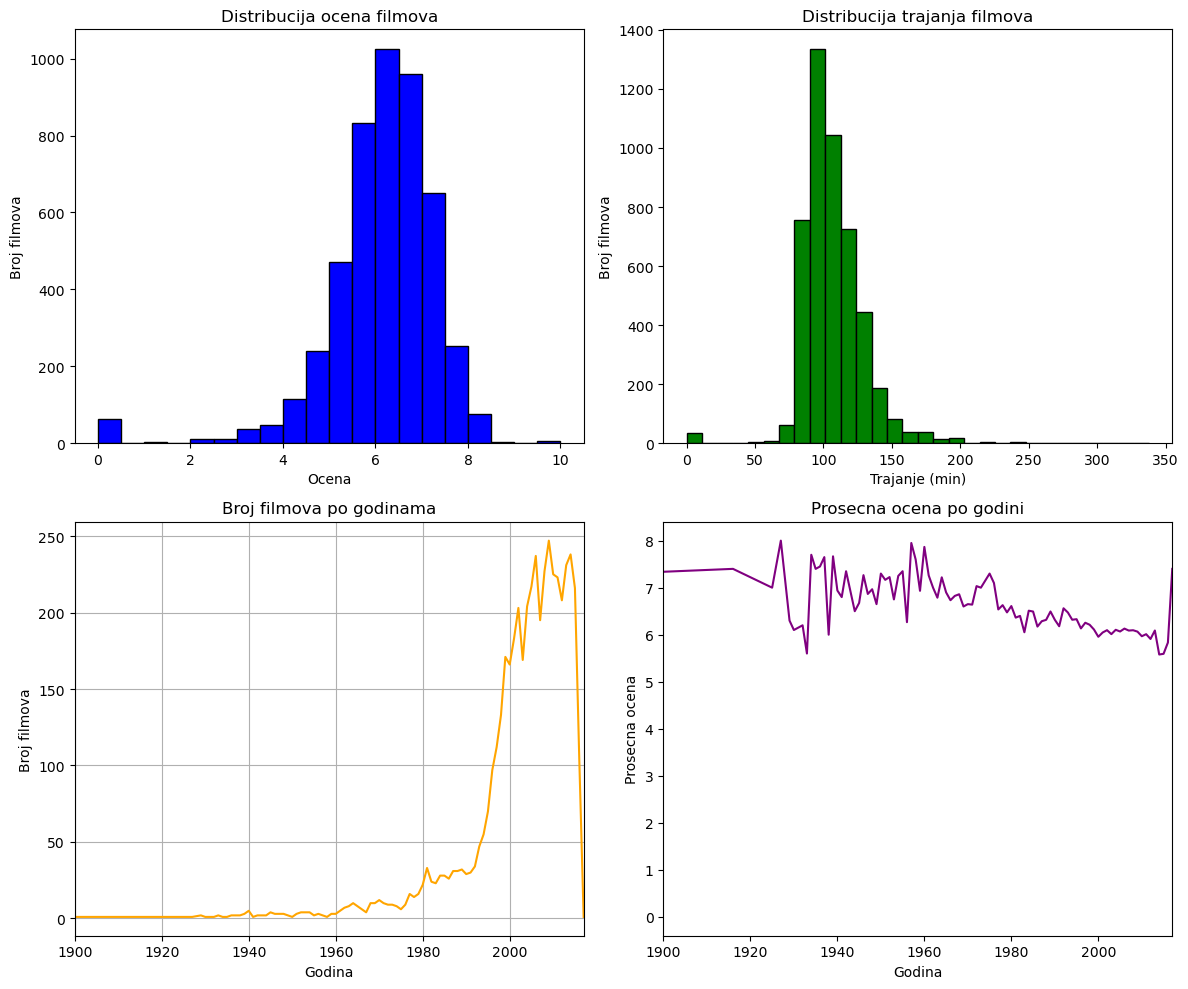

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].hist(movies['vote_average'], bins=20, color='blue', edgecolor='black')
axs[0, 0].set_title('Distribucija ocena filmova')
axs[0, 0].set_xlabel('Ocena')
axs[0, 0].set_ylabel('Broj filmova')

axs[0, 1].hist(movies['runtime'], bins=30, color='green', edgecolor='black')
axs[0, 1].set_title('Distribucija trajanja filmova')
axs[0, 1].set_xlabel('Trajanje (min)')
axs[0, 1].set_ylabel('Broj filmova')

movies_by_year = movies['year'].value_counts().sort_index()
axs[1, 0].plot(movies_by_year.index, movies_by_year.values, color='orange')
axs[1, 0].set_title('Broj filmova po godinama')
axs[1, 0].set_xlabel('Godina')
axs[1, 0].set_ylabel('Broj filmova')
axs[1, 0].grid(True)
axs[1, 0].set_xlim(1900, movies_by_year.index.max())

avg_rating_by_year = movies.groupby('year')['vote_average'].mean()
axs[1, 1].plot(avg_rating_by_year.index, avg_rating_by_year.values, color='purple')
axs[1, 1].set_title('Prosecna ocena po godini')
axs[1, 1].set_xlabel('Godina')
axs[1, 1].set_ylabel('Prosecna ocena')
axs[1, 1].set_xlim(1900, avg_rating_by_year.index.max())

plt.tight_layout()
plt.show()

In [27]:
movies = movies[movies["vote_average"] > 0.0]
movies = movies[movies["runtime"] > 0.0]

In [33]:
movies.head()
#movies.isnull().sum().sum()

,budget,genres,popularity,release_date,runtime,title,vote_average,vote_count,cast,director,year
0,237000000,Action Adventure Fantasy Science Fiction,150.437577,2009-12-10,162.0,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron,2009
1,300000000,Adventure Fantasy Action,139.082615,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski,2007
2,245000000,Action Adventure Crime,107.376788,2015-10-26,148.0,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes,2015
3,250000000,Action Crime Drama Thriller,112.312950,2012-07-16,165.0,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan,2012
4,260000000,Action Adventure Science Fiction,43.926995,2012-03-07,132.0,John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton,2012


In [31]:
print(len(movies))

4717


In [34]:
movies.to_csv('processed_movies.csv', index = False)